# Credit Risk Prediction Using Machine Learning

## 1. Import Libraries

In [37]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

plt.style.use("ggplot")

Load Dataset

In [38]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## 3. Data Preprocessing

### 3.1 Remove Unnecessary Columns

In [39]:
df.drop("Unnamed: 0", axis=1, inplace=True)

## Data Preprocessing

The exploratory data analysis identified that the `Unnamed: 0` column represents an automatically generated index rather than meaningful customer information.

This column was removed because it does not contribute to predicting credit risk and could introduce unnecessary noise into the machine learning model.

### 3.2 Handle Missing Values

In [40]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [41]:
# Replace missing values with 'Unknown'

df["Saving accounts"] = df["Saving accounts"].fillna("Unknown")
df["Checking account"] = df["Checking account"].fillna("Unknown")

In [42]:
#check  again  missing  values
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0
Risk,0




#### Missing Value Treatment

The dataset contained missing values in the **Saving accounts** and **Checking account** variables.

Instead of removing observations or imputing the most frequent category, the missing values were replaced with a new category named **"Unknown"**.

This approach preserves all customer records while allowing the machine learning model to learn whether missing financial account information is associated with credit risk.

### 3.3 Encode Categorical Variables

In [43]:
#Check the Data Types
df.dtypes

,0
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object
Risk,object


In [44]:
#create categorical  as  one group and  name  it  categorical_columns
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose',
       'Risk'],
      dtype='object')

In [45]:
#Encode the Variables

label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [46]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,1
1,22,0,2,1,1,2,5951,48,5,0
2,49,1,1,1,1,0,2096,12,3,1
3,45,1,2,0,1,1,7882,42,4,1
4,53,1,2,0,1,1,4870,24,1,0


## Interpretation

Machine learning algorithms require numerical input. Therefore, all categorical variables were converted into numerical values using **Label Encoding**.

The encoded variables include:

- Sex
- Housing
- Saving accounts
- Checking account
- Purpose
- Risk

This transformation enables the machine learning algorithms to process the categorical features during model training.

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int64
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int64
 4   Saving accounts   1000 non-null   int64
 5   Checking account  1000 non-null   int64
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int64
 9   Risk              1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB


### 3.4 Split Features and Target

In [48]:
#creating feature x and target y
X = df.drop("Risk", axis=1)

y = df["Risk"]

#print shape
print(X.shape)
print(y.shape)

(1000, 9)
(1000,)




The dataset was divided into:

- **Features (X):** Customer characteristics used to predict credit risk.
- **Target (y):** The `Risk` variable representing whether a customer is classified as Good or Bad credit risk.

Separating the predictors from the target variable is a standard step before training supervised machine learning models.

### 3.5 Train-Test Split

In [49]:
#split  the  data  into 80% train set and 20% test set
X_train,X_test,y_train,y_test = train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=y)

In [50]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (800, 9)
Testing Features: (200, 9)
Training Target: (800,)
Testing Target: (200,)




The dataset was divided into training and testing sets using an **80:20 split**.

- **Training Set (80%)** was used to train the machine learning models.
- **Testing Set (20%)** was reserved for evaluating model performance on unseen data.

The `stratify=y` parameter was used to preserve the original distribution of Good and Bad credit risk customers in both datasets.

### 3.6 Feature Scaling

In [51]:
#feature scaling to  ensures all  variable  has same standard scale

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [52]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(800, 9)
(200, 9)




The numerical features were standardized using **StandardScaler**.

Feature scaling transforms variables to have a mean of zero and a standard deviation of one, ensuring that variables measured on different scales contribute fairly during model training.

The scaler was fitted only on the training data and then applied to the testing data to prevent data leakage.

## 4. Model Development

### 4.1 Logistic Regression

In [53]:
#inistatiate logisticregression model

log_model = LogisticRegression(random_state=42)

#fit model

log_model.fit(X_train_scaled, y_train)

#make prediction

y_pred_log = log_model.predict(X_test_scaled)
y_pred_log[0:5]

array([1, 0, 0, 1, 0])

## 5. Model Evaluation

Accuracy

In [54]:
#create Accuracy

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(log_accuracy,4))

Logistic Regression Accuracy: 0.665


Confusion Matrix

In [55]:
#create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[ 11  49]
 [ 18 122]]


Classification Report

In [56]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.38      0.18      0.25        60
           1       0.71      0.87      0.78       140

    accuracy                           0.67       200
   macro avg       0.55      0.53      0.52       200
weighted avg       0.61      0.67      0.62       200



ROC-AUC Score

In [57]:
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])

print("ROC-AUC:", round(log_auc,4))

ROC-AUC: 0.6623


## Logistic Regression Results

### Model Performance

| Metric | Score |
|---------|-------|
| Accuracy | 66.5% |
| ROC-AUC | 0.6623 |

### Key Findings

- The Logistic Regression model achieved an overall accuracy of **66.5%**.
- The ROC-AUC score of **0.6623** indicates fair discrimination between Good and Bad credit risk customers.
- The model performed well in identifying **Good** credit risk customers but struggled to correctly identify **Bad** credit risk customers.
- The recall for the Bad credit risk class was only **18%**, meaning that many high-risk customers were incorrectly classified as low-risk.

### Business Interpretation

Although Logistic Regression provides a useful baseline model, its ability to detect Bad credit risk customers is limited. In a lending environment, failing to identify risky borrowers can lead to increased loan defaults and financial losses.

For this reason, more advanced machine learning models such as Decision Trees and Random Forests will be evaluated to determine whether they can improve the detection of high-risk customers while maintaining strong overall predictive performance.

### 4.2 Decision Tree

In [58]:
#inistatiate logisticregression model

tree_model = DecisionTreeClassifier(random_state=42)
#fit model

tree_model.fit(X_train, y_train)
#predict

y_pred_tree = tree_model.predict(X_test)
y_pred_tree[0:5]

array([1, 0, 1, 1, 1])

## 5. Model Evaluation

Accuracy

In [59]:
tree_accuracy = accuracy_score(y_test,y_pred_tree)
print("Decision Tree Accuracy:", round(tree_accuracy,4))

Decision Tree Accuracy: 0.64


Confusion Matrix

In [60]:
print(confusion_matrix(y_test, y_pred_tree))

[[ 22  38]
 [ 34 106]]


Classification Report

In [61]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.39      0.37      0.38        60
           1       0.74      0.76      0.75       140

    accuracy                           0.64       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.63      0.64      0.64       200



ROC-AUC

In [62]:
tree_auc = roc_auc_score(
    y_test,
    tree_model.predict_proba(X_test)[:,1]
)

print("Decision Tree ROC-AUC:", round(tree_auc,4))

Decision Tree ROC-AUC: 0.5619




### Model Performance

| Metric | Score |
|---------|-------|
| Accuracy | 64.0% |
| ROC-AUC | 0.5619 |

### Key Findings

- The Decision Tree achieved an overall accuracy of **64.0%**.
- The model improved the detection of **Bad** credit risk customers compared to Logistic Regression, increasing recall from **18%** to **37%**.
- However, the overall discrimination ability, measured by ROC-AUC, decreased to **0.5619**.
- The model correctly identified more risky borrowers but also misclassified a larger number of good customers.

### Business Interpretation

The Decision Tree demonstrates a better ability to detect high-risk borrowers than Logistic Regression, which is valuable for reducing potential loan defaults.

However, the lower ROC-AUC score suggests that the model has weaker overall predictive performance. Additional models such as Random Forest will be evaluated to determine whether they can improve both overall accuracy and the detection of high-risk customers.

### 4.3 Random Forest

In [63]:
#inistatiate logisticregression model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
#fit model
rf_model.fit(X_train, y_train)
#predict
y_pred_rf = rf_model.predict(X_test)
y_pred_rf[0:5]

array([1, 1, 1, 1, 1])

## 5. Model Evaluation

Accuracy

In [64]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy,4))

Random Forest Accuracy: 0.745


Confusion Matrix

In [65]:
print(confusion_matrix(y_test, y_pred_rf))

[[ 26  34]
 [ 17 123]]


Classification Report

In [66]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.60      0.43      0.50        60
           1       0.78      0.88      0.83       140

    accuracy                           0.74       200
   macro avg       0.69      0.66      0.67       200
weighted avg       0.73      0.74      0.73       200



ROC-AUC

In [67]:
rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

print("Random Forest ROC-AUC:", round(rf_auc,4))

Random Forest ROC-AUC: 0.747




### Model Performance

| Metric | Score |
|---------|-------|
| Accuracy | 74.5% |
| ROC-AUC | 0.7470 |

### Key Findings

- The Random Forest model achieved the highest overall accuracy (**74.5%**) among all evaluated models.
- The model also achieved the highest ROC-AUC score (**0.7470**), indicating good discrimination between Good and Bad credit risk customers.
- Compared to Logistic Regression and Decision Tree, Random Forest identified a larger proportion of Bad credit risk customers while maintaining strong performance for Good credit risk customers.
- The ensemble learning approach reduced overfitting compared to a single Decision Tree and improved overall predictive performance.

### Business Interpretation

Random Forest demonstrated the strongest predictive performance in this project. Its ability to identify both Good and Bad credit risk customers makes it a suitable model for supporting loan approval decisions.

By improving the detection of high-risk borrowers, the model can help financial institutions reduce potential loan defaults while maintaining efficient approval of creditworthy applicants.

## 5. Model Evaluation

## 6. Model Comparison



| Model | Accuracy | ROC-AUC | Recall (Bad Risk) |
|---------|---------:|---------:|------------------:|
| Logistic Regression | 66.5% | 0.6623 | 18% |
| Decision Tree | 64.0% | 0.5619 | 37% |
| **Random Forest** | **74.5%** | **0.7470** | **43%** |

### Best Model

Among the evaluated models, **Random Forest** achieved the highest Accuracy and ROC-AUC score while also providing the best detection of Bad credit risk customers.

Based on these results, Random Forest was selected as the final model for this project.


## 7. Feature Importance

Extract Feature Importance

In [68]:
# Extract feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,Credit amount,0.256548
0,Age,0.177604
7,Duration,0.160331
5,Checking account,0.127120
8,Purpose,0.088280
4,Saving accounts,0.066530
2,Job,0.052079
3,Housing,0.040833
1,Sex,0.030676


Visualize Feature Importance

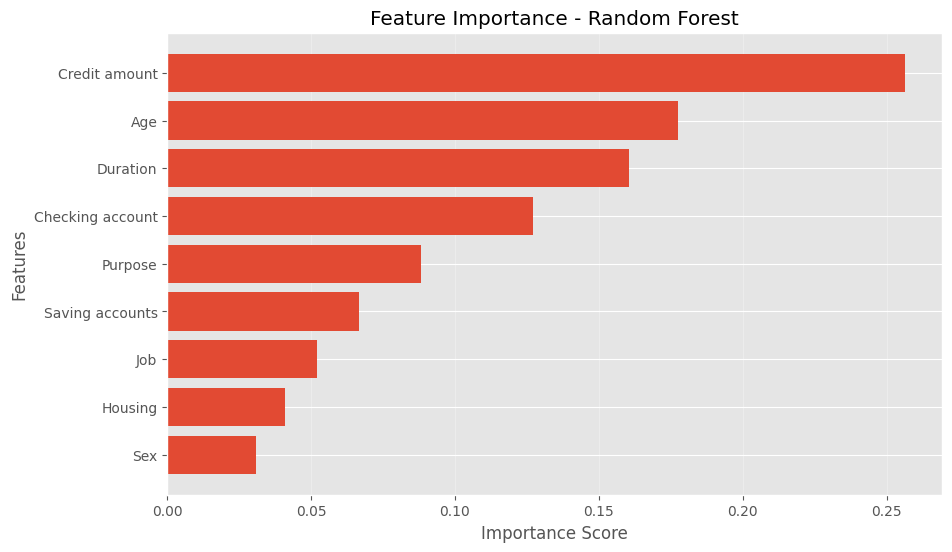

In [69]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()



### Key Findings

The Random Forest model identified the following variables as the most influential predictors of credit risk:

1. **Credit Amount**
2. **Age**
3. **Loan Duration**
4. **Checking Account Status**
5. **Loan Purpose**

Among all variables, **Credit Amount** had the greatest influence on the model's predictions, followed by **Age** and **Loan Duration**.

Variables such as **Housing**, **Job**, and **Sex** had relatively lower importance, indicating they contributed less to predicting customer credit risk.

### Business Interpretation

The results suggest that financial characteristics are more important than demographic characteristics when assessing credit risk.

Customers requesting larger loan amounts or longer repayment periods may present different levels of risk, making these variables particularly valuable during loan evaluation.

Checking account status also plays an important role, suggesting that a customer's banking relationship provides useful information for predicting repayment behavior.

These findings can help financial institutions focus on the most influential factors when designing credit risk assessment policies and improving loan approval decisions.

Save the Random Forest Model


In [70]:
import joblib

In [71]:
joblib.dump(rf_model, "credit_risk_random_forest.pkl")

['credit_risk_random_forest.pkl']

Verify the Model Loads Correctly

In [72]:
loaded_model = joblib.load("credit_risk_random_forest.pkl")

print("Model loaded successfully!")

Model loaded successfully!


## 8. Business Recommendations



Based on the exploratory data analysis and machine learning results, the following recommendations are proposed for financial institutions:

## 1. Prioritize High Loan Amounts

The Random Forest model identified **Credit Amount** as the most influential predictor of credit risk. Applications requesting larger loan amounts should undergo additional credit assessment before approval.

---

## 2. Monitor Long Loan Durations

Longer repayment periods were associated with higher credit risk. Financial institutions should carefully evaluate customers requesting extended loan durations and consider stricter approval criteria.

---

## 3. Strengthen Customer Financial Profile Assessment

Checking account status and saving account information were important predictors of credit risk. Banks should incorporate customer banking behavior into their credit scoring process.

---

## 4. Apply Risk-Based Loan Approval

Rather than treating all applicants equally, financial institutions should use predictive models to assign risk scores and tailor lending decisions accordingly.

---

## 5. Use Machine Learning as a Decision Support Tool

The Random Forest model achieved the best overall predictive performance and can assist loan officers by identifying high-risk applicants before loan approval.

Machine learning should complement—not replace—human judgment in the credit approval process.

## 9. Conclusion



This project developed a machine learning solution for predicting customer credit risk using the German Credit Dataset.

The project followed a complete data science workflow, including:

- Data understanding
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Machine learning model development
- Model evaluation
- Feature importance analysis
- Business recommendations

Three machine learning models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among the evaluated models, **Random Forest** achieved the best performance with:

- Accuracy: **74.5%**
- ROC-AUC: **0.747**

Feature importance analysis showed that **Credit Amount**, **Age**, and **Loan Duration** were the strongest predictors of customer credit risk.

The developed model demonstrates how machine learning can support financial institutions by improving credit risk assessment, reducing potential loan defaults, and enabling more informed lending decisions.

Future improvements may include hyperparameter tuning, testing additional ensemble models such as XGBoost, and deploying the model as a web application for real-time credit risk prediction.